# Introductory Tutorial 

The first main goal of this notebook is to get everyone up to speed in terms of running python code in jupyter notebooks, and our tutorials in particular. The second goal is to illustrate some basic concepts from probability theory.

Prepared by Mihály Bányai, 2026. mihaly.s.banyai@gmail.com, https://visionlab-ceu.org/people/mihaly-banyai/ 

Running the following box should install all packages that we'll need over the course of the semester. You can do this inside a dedicated virtual environment (venv, conda, etc.), in the global python environment of your computer, or even on google colabs. My notebooks are tested with the python kernel version 3.12.5, but they should work with other kernels not extremely distant from this in terms of version number (definitely use Python 3 though).

In [1]:
!pip install numpy scipy matplotlib ipynb levenshtein daft-pgm ipympl

  Obtaining dependency information for ipynb from https://files.pythonhosted.org/packages/31/42/4c0bbb66390e3a68e04ebf134c8d074a00c18b5882293f8ace5f7497fbf0/ipynb-0.5.1-py3-none-any.whl.metadata
  Obtaining dependency information for levenshtein from https://files.pythonhosted.org/packages/0e/fd/42e28a86e2f04a2e064faa1eab7d81a35fb111212b508ce7e450f839943d/levenshtein-0.27.3-cp311-cp311-macosx_10_9_x86_64.whl.metadata
  Obtaining dependency information for daft-pgm from https://files.pythonhosted.org/packages/6a/10/8177be1c256b10b5a7b22efad96d74568ab4f4cdac22056e742f5284a409/daft_pgm-0.1.4-py3-none-any.whl.metadata
  Obtaining dependency information for rapidfuzz<4.0.0,>=3.9.0 from https://files.pythonhosted.org/packages/76/25/5b0a33ad3332ee1213068c66f7c14e9e221be90bab434f0cb4defa9d6660/rapidfuzz-3.14.3-cp311-cp311-macosx_10_9_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.2/172.2 kB 2.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 M

The following box imports some basic packages.

In [2]:
import numpy as np  # for handling arrays
import scipy as sp  # scientific tools, e.g. probability distributions
import matplotlib.pyplot as plt  # plotting
import matplotlib as mpl  # some plotting-related functions need this separately
import daft  # to plot graphical Bayesian models nicely
#the following lets you zoom into and explore figures, may require you to restart the kernel:
%matplotlib widget 

We will look at posterior inference in a Bayesian generative model. The model has one observed variable, $k$, and one latent variable, $\lambda$. The following code plots a nice visual representation of the model using the daft language. You don't need to learn this, but it's useful for comunicating modelling ideas. 

The $\alpha$ and $\theta$ parameters in the model indicate the parameters of the Gamma prior distribution for the latent $\lambda$ variable. These we consider fixed and given. The shading of the circle of $k$ indicates that we will receive observations for this variable. The unshaded circle of $\lambda$ indicates that this is a latent variable that we may infer using observations of a different variable ($k$ in this case) and the model itself. The plate around $k$ with the number $n$ indicates that we will receive $n$ observations of $k$ at the same time. $\lambda$ not being on the plate means that there will be a single posterior distribution over it calculated from all $n$ observations of $k$.

The model will be completed by giving the formulas for the prior distributionand likelihood function:

$p(\lambda) = Gamma(\lambda; \alpha, \theta)$

$p(k \mid \lambda) = Poisson(k; \lambda)$

<Axes: >

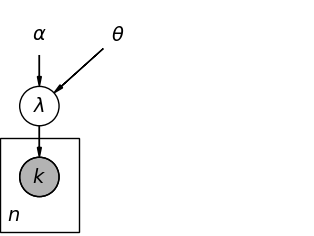

In [3]:
mpl.rc("font", family="serif", size=14)
pgm = daft.PGM((4, 3), origin=(0.15, 0.15))
pgm.add_node(daft.Node("k", r"$k$", 0.65, 0.9, observed=True))
pgm.add_node(daft.Node("lambda", r"$\lambda$", 0.65, 1.8, observed=False))
pgm.add_node(daft.Node("alpha", r"$\alpha$", 0.65, 2.7, observed=False, plot_params={"ec": "none"}))
pgm.add_node(daft.Node("theta", r"$\theta$", 1.65, 2.7, observed=False, plot_params={"ec": "none"}))
pgm.add_plate(daft.Plate([0.15, 0.2, 1., 1.2],label=r"$n$"))
pgm.add_edge("lambda","k")
pgm.add_edge("alpha","lambda")
pgm.add_edge("theta","lambda")
pgm.render()

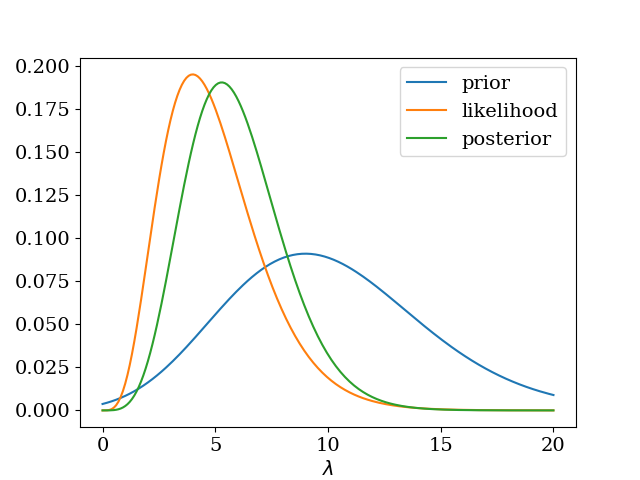

In [4]:
plt.figure()
# first we define the range over which we want to calculate distributions of the latent variable
# note that lambda is a keyword in Python (related to lambda calculus), so you can't have a variable named lambda, you can use lamb, lambda_, etc.
lambda_support = np.linspace(0, 20, 200)
alpha, theta = 20, -10
prior = np.array([sp.stats.gamma(alpha,theta).pdf(lamb) for lamb in lambda_support])
plt.plot(lambda_support, prior, label="prior")

# we receive the observations and calculate the likelihood function
observations = [4]
likelihood = np.array([np.array([sp.stats.poisson(lamb).pmf(obs) for obs in observations]).prod() for lamb in lambda_support])
plt.plot(lambda_support, likelihood, label="likelihood")

# we calculate the posterior using Bayes' theorem
unnorm_posterior = likelihood * prior
# doing the normalisation properly requires taking into account how densely we evaluate the functions
grid_step_size = (lambda_support[-1] - lambda_support[0]) / len(lambda_support)
posterior = unnorm_posterior / (unnorm_posterior.sum() * grid_step_size)
plt.plot(lambda_support, posterior, label="posterior")
plt.xlabel(r"$\lambda$")
plt.legend()